The main goal of this notebook is to **compare the performance of different YOLOv8 trained models** over the same validation dataset. The models were trained over four different datasets made of:
1. **Mono Real**:  879 real images
2. **+10% fake**:  879 real + 88 synthetic images
3. **+50% fake**:  879 real + 439 synthetic images
4. **+100% fake**: 879 real + 879 sythetic images
5. **Mono Fake**:  879 synthetic images

# IMPORTS

In [ ]:
import numpy as np 
import pandas as pd
import os

# Import Data Inputs
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        
# Import and download datasets
!pip install gdown
!gdown --folder https://drive.google.com/drive/folders/1UabAUSvwcA8Lmep245sM1DMNNJ1deD6T -O ./data/       # Image dataset download
!gdown --folder https://drive.google.com/drive/u/0/folders/1HKCXBZcltonnDdbjtDT6RQD9ZcrGBnyj -O ./        # YOLO trained weights download

# Installing YOLO dependencies
!pip install ultralytics

# DATA PRE-PROCESSING
We process the Validation dataset made of DENTEX images.

In [ ]:
import zipfile
from pathlib import Path

DATA_DIR = Path("/kaggle/working/data/YOLOv8")

## ZIP Decompression
ZIP_FILE = DATA_DIR / 'QE-VAL.zip'

print("Starting ZIP decompression...")
if ZIP_FILE.exists():
    extract_dir = DATA_DIR
    print(f"Extracting QE-VAL.zip in {extract_dir}...")
    
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)            
    ZIP_FILE.unlink()
    
else:
    print(f"WARNING: zip file not found at {path_zip}")

print("Extraction complete!")

In [ ]:
import os
import json
import shutil
import yaml
from tqdm import tqdm
import cv2
from collections import defaultdict
from pathlib import Path


def resize_and_save(in_img_dir, in_json_path, out_img_dir, out_json_path, prefix, target_height=512):
    print(f"\nProcessing: {in_img_dir}")
    print(f"Saving in: {out_img_dir}")
    print(f"Applying prefix: '{prefix}' | Resizing to {target_height}px")

    # Creating destination folders
    os.makedirs(out_img_dir, exist_ok=True)
    os.makedirs(os.path.dirname(out_json_path), exist_ok=True)

    # Reading JSON file
    with open(in_json_path, 'r') as f:
        data = json.load(f)

    # Collecting annotations in a dictionary
    annotations_by_image = defaultdict(list)
    for ann in data['annotations']:
        annotations_by_image[ann['image_id']].append(ann)

    processed_count = 0
    resized_count = 0
    copied_count = 0
    missing_count = 0

    # Iterating for JSON images
    for img_info in data['images']:
        old_name = img_info['file_name']
        img_id = img_info['id']

        # renaming files
        if old_name.startswith(prefix):
            new_name = old_name
        else:
            new_name = f"{prefix}{old_name}"

        img_info['file_name'] = new_name          # updating JSON name

        old_path = os.path.join(in_img_dir, old_name)
        new_path = os.path.join(out_img_dir, new_name)

        if not os.path.exists(old_path):
            print(f"    ! Image not found: {old_path}")
            missing_count += 1
            continue

        # DOWNSAMPLING
        img = cv2.imread(old_path)
        if img is None:
            print(f"    ! Can't read image: {old_path}")
            continue

        orig_h, orig_w = img.shape[:2]

        # Check img size
        if orig_h == target_height:
            shutil.copy(old_path, new_path)
            copied_count += 1
            processed_count += 1
            continue

        # Evaluating scale factor
        scale = target_height / float(orig_h)
        new_w = int(orig_w * scale)
        new_h = target_height

        # Resize img and saving
        resized_img = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)
        cv2.imwrite(new_path, resized_img)
        resized_count += 1
        processed_count += 1

        # JSON UPDATE
        img_info['width'] = new_w
        img_info['height'] = new_h

        # Scaling annotations
        for ann in annotations_by_image.get(img_id, []):
            # Resize BBox [x, y, width, height]
            if 'bbox' in ann:
                ann['bbox'] = [val * scale for val in ann['bbox']]

            # Scale masks (Polygons)
            if 'segmentation' in ann:
                new_segmentation = []
                for polygon in ann['segmentation']:
                    new_polygon = [val * scale for val in polygon]
                    new_segmentation.append(new_polygon)
                ann['segmentation'] = new_segmentation

            # Scale area
            if 'area' in ann:
                ann['area'] = ann['area'] * (scale ** 2)

    # SAVING JSON FILE ON NEW PATH
    with open(out_json_path, 'w') as f:
        json.dump(data, f)

    print(f" -> Number of processed images: {processed_count}")
    if missing_count > 0:
        print(f" -> WARNING: Images found on JSON but not found in the original folder: {missing_count}")


## PATH CONFIG
BASE_DIR = Path("/kaggle/working/data/YOLOv8")

# -- VALIDATION QE --
QE_VAL_IMG_IN = f'{BASE_DIR}/QE-VAL/images'
QE_VAL_JSON_IN = f'{BASE_DIR}/QE-VAL/labels/test_annotations.json'
QE_VAL_IMG_OUT = f'{BASE_DIR}/QE_512-VAL/images'
QE_VAL_JSON_OUT = f'{BASE_DIR}/QE_512-VAL/labels/test_annotations.json'


## PROCESSING
resize_and_save(QE_VAL_IMG_IN, QE_VAL_JSON_IN, QE_VAL_IMG_OUT, QE_VAL_JSON_OUT, "QE_")

print("\nResizing complete!")

Next, we convert the JSON annotation files to YOLO-compatible .txt files. During this process, the specific tooth IDs are remapped to class IDs ranging from 0 to 31.

In [ ]:
## PATH CONFIG
QE_VAL_IMG = f'{BASE_DIR}/QE_512-VAL/images'
QE_VAL_JSON = f'{BASE_DIR}/QE_512-VAL/labels/test_annotations.json'

QEM_dataset = '/kaggle/working/QEModel'


# Creating train and val folders
QEM_IMG_TRAIN = os.path.join(QEM_dataset, 'images', 'train')
QEM_IMG_VAL = os.path.join(QEM_dataset, 'images', 'val')
QEM_LBL_TRAIN = os.path.join(QEM_dataset, 'labels', 'train')
QEM_LBL_VAL = os.path.join(QEM_dataset, 'labels', 'val')

os.makedirs(QEM_IMG_TRAIN, exist_ok=True)
os.makedirs(QEM_IMG_VAL, exist_ok=True)
os.makedirs(QEM_LBL_TRAIN, exist_ok=True)
os.makedirs(QEM_LBL_VAL, exist_ok=True)


## CONVERSION FUNCTION
def convert2yolo(json_path, source_img_dir, dest_img_dir, dest_lbl_dir, dataset_name):
    print(f"\nElaborazione dataset {dataset_name}...")

    with open(json_path, 'r') as f:
        data = json.load(f)

    img_info_dict = {img['id']: img for img in data['images']}

    annotations_by_image = defaultdict(list)
    for ann in data['annotations']:
        annotations_by_image[ann['image_id']].append(ann)

    for img_id, img_info in tqdm(img_info_dict.items(), desc=f"Converting {dataset_name}"):
        file_name = img_info['file_name']
        width = img_info['width']
        height = img_info['height']

        src_img_path = os.path.join(source_img_dir, file_name)

        if not os.path.exists(src_img_path):
            continue

        txt_file_name = os.path.splitext(file_name)[0] + '.txt'
        txt_path = os.path.join(dest_lbl_dir, txt_file_name)

        with open(txt_path, 'w') as f_out:
            for ann in annotations_by_image.get(img_id, []):
                # category_id_1: Quadrant (0-3), category_id_2: Enumeration (0-7)
                cat1 = ann['category_id_1']
                cat2 = ann['category_id_2']

                # ID (0-31)
                yolo_class_id = (cat1 * 8) + cat2


                for polygon in ann['segmentation']:
                    norm_polygon = []
                    for i in range(0, len(polygon), 2):
                        x_norm = max(0.0, min(1.0, polygon[i] / width))
                        y_norm = max(0.0, min(1.0, polygon[i+1] / height))
                        norm_polygon.append(f"{x_norm:.6f} {y_norm:.6f}")

                    f_out.write(f"{yolo_class_id} " + " ".join(norm_polygon) + "\n")

        # copy img
        dest_img_path = os.path.join(dest_img_dir, file_name)
        if not os.path.exists(dest_img_path):
            shutil.copy(src_img_path, dest_img_path)


## Processing Validation dataset
convert2yolo(QE_VAL_JSON, QE_VAL_IMG, QEM_IMG_VAL, QEM_LBL_VAL, "QE Validation")

print("\nWriting file data.yaml...")

class_names = { (q * 8 + e): f"Q{q}_E{e}" for q in range(4) for e in range(8) }

yaml_data = {
    'train': os.path.join(QEM_dataset, 'images', 'train'),
    'val': os.path.join(QEM_dataset, 'images', 'val'),
    'nc': 32,
    'names': class_names
}


yaml_path = os.path.join(QEM_dataset, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"Dataset and data.yaml ready in: {QEM_dataset}")

--------------------------


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ultralytics import YOLO

## PATH CONFIG
yaml_path = '/kaggle/working/QEModel/data.yaml'

models_dict = {
    'Mono Real': '/kaggle/working/WEIGHTS/YOLOv8m_weights.pt',
    '+10% Fake': '/kaggle/working/WEIGHTS/YOLOv8m_AUG10_weights.pt',
    '+50% Fake': '/kaggle/working/WEIGHTS/YOLOv8m_AUG50_weights.pt',
    '+100% Fake': '/kaggle/working/WEIGHTS/YOLOv8m_AUG100_weights.pt',
    'Mono Fake': '/kaggle/working/WEIGHTS/YOLOv8m_FULL-SYNTH_weights.pt'
}

def classify_tooth(class_name):
    if any(e in class_name for e in ['E0', 'E1', 'E2', 'E3']):
        return 'Front Teeth (E0-E3)'
    else:
        return 'Back Teeth (E4-E7)'

## DATA EXTRACTION
print("Starting validation process for all models...\n")
all_data = []

for model_name, model_path in models_dict.items():
    print(f"Evaluating {model_name}...")
    try:
        model = YOLO(model_path)
        metrics = model.val(data=yaml_path, split='val', verbose=False)
        
        class_indices = metrics.seg.ap_class_index
        class_names = [metrics.names[i] for i in class_indices]
        
        df = pd.DataFrame({
            'Model': model_name,
            'Classe': class_names,
            'mAP50': metrics.seg.ap50,
            'mAP50_perc': metrics.seg.ap50 * 100,
            'Precision_perc': metrics.seg.p * 100,
            'Recall_perc': metrics.seg.r * 100
        })
        
        df['Gruppo'] = df['Classe'].apply(classify_tooth)
        all_data.append(df)
        print(f"[{model_name}] Metrics successfully extracted.\n")
        
    except Exception as e:
        print(f"Error evaluating {model_name}: {e}\n")


master_df = pd.concat(all_data, ignore_index=True)


 GLOBAL METRICS COMPARISON (Mean across all classes)
            mAP50_perc  Precision_perc  Recall_perc  F1_Score_perc
Model                                                             
Mono Real        92.27           92.33        93.62          92.97
+10% Fake        94.53           92.62        93.20          92.91
+50% Fake        94.68           93.31        93.10          93.20
+100% Fake       94.63           92.73        92.80          92.76
Mono Fake         4.16            6.18        16.70           9.02

 mAP50 (%) COMPARISON BY TOOTH GROUP
Model                Mono Real  +10% Fake  +50% Fake  +100% Fake  Mono Fake
Gruppo                                                                     
Back Teeth (E4-E7)       91.73      93.69      94.75       94.25       0.90
Front Teeth (E0-E3)      92.82      95.36      94.62       95.02       7.41

 mAP50 (%) COMPARISON BY SPECIFIC CLASS
Model   Mono Real  +10% Fake  +50% Fake  +100% Fake  Mono Fake
Classe                         

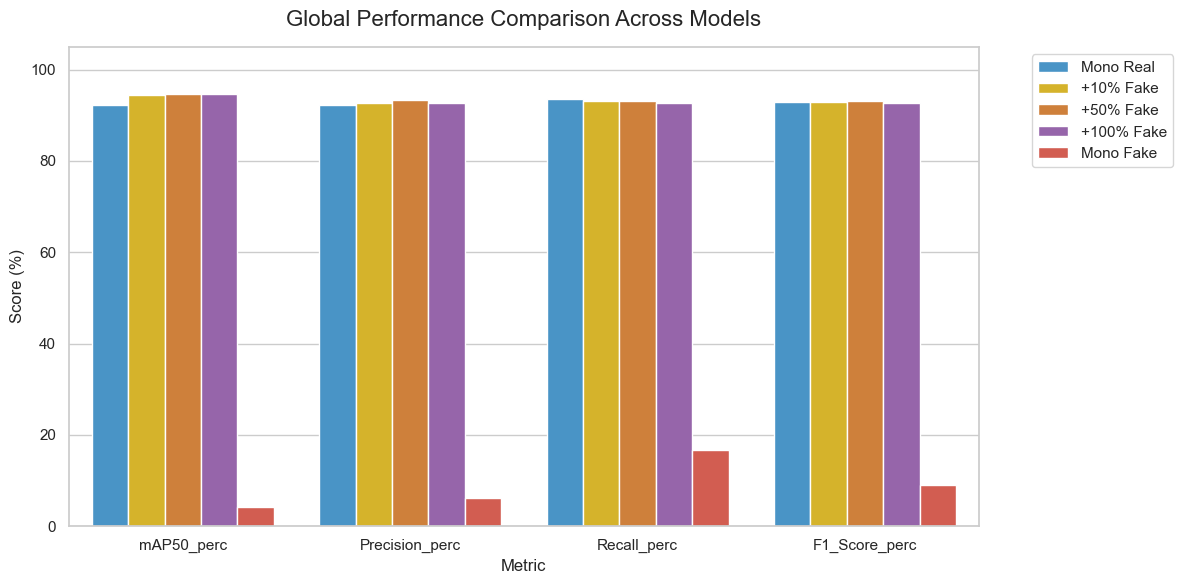

Saved class comparison plot: /kaggle/working/class_comparison.png


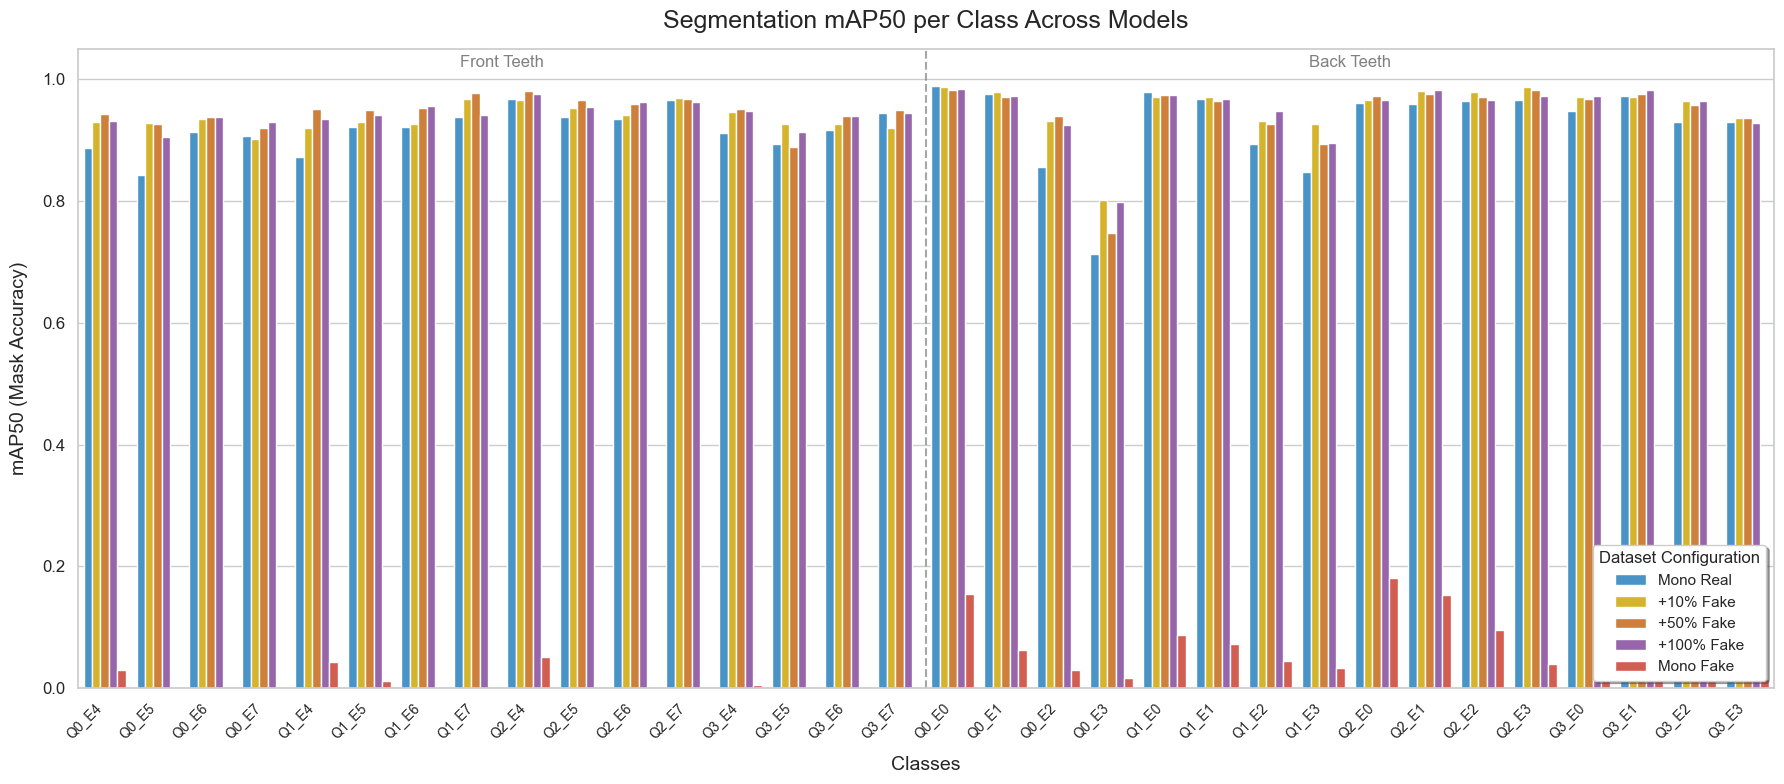

In [7]:
## DISPLAYING TEXT TABLES
print("\n" + "="*80)
print(" GLOBAL METRICS COMPARISON (Mean across all classes)")
print("="*80)
global_metrics = master_df.groupby('Model')[['mAP50_perc', 'Precision_perc', 'Recall_perc']].mean()

global_metrics['F1_Score_perc'] = 2 * (global_metrics['Precision_perc'] * global_metrics['Recall_perc']) / (global_metrics['Precision_perc'] + global_metrics['Recall_perc'])
global_metrics['F1_Score_perc'] = global_metrics['F1_Score_perc'].fillna(0)

global_metrics = global_metrics[['mAP50_perc', 'Precision_perc', 'Recall_perc', 'F1_Score_perc']]

global_metrics = global_metrics.reindex(models_dict.keys())
print(global_metrics.round(2).to_string())

print("\n" + "="*80)
print(" mAP50 (%) COMPARISON BY TOOTH GROUP")
print("="*80)
group_metrics = master_df.pivot_table(index='Gruppo', columns='Model', values='mAP50_perc', aggfunc='mean')
group_metrics = group_metrics[list(models_dict.keys())] 
print(group_metrics.round(2).to_string())

print("\n" + "="*80)
print(" mAP50 (%) COMPARISON BY SPECIFIC CLASS")
print("="*80)
class_metrics = master_df.pivot_table(index='Classe', columns='Model', values='mAP50_perc', aggfunc='mean')
class_metrics = class_metrics[list(models_dict.keys())] 
print(class_metrics.round(2).to_string())
print("\n")


## PLOTTING
sns.set_theme(style="whitegrid")
model_palette = ['#3498db', '#f1c40f', '#e67e22', '#9b59b6', '#e74c3c']

# Plot 1: Global metrics per model
plt.figure(figsize=(12, 6))
global_metrics_melted = global_metrics.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score (%)')
sns.barplot(data=global_metrics_melted, x='Metric', y='Score (%)', hue='Model', palette=model_palette)
plt.title('Global Performance Comparison Across Models', fontsize=16, fontweight='bold', pad=15)
plt.ylim(0, 105)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('/kaggle/working/global_comparison.png', dpi=300, bbox_inches='tight')
print("Saved global comparison plot: /kaggle/working/global_comparison.png")
plt.show()

# Plot 2: mAP50 per class grouped by Model
plt.figure(figsize=(18, 8))

master_df = master_df.sort_values(by=['Gruppo', 'Classe'])

ax = sns.barplot(data=master_df, x='Classe', y='mAP50', hue='Model', palette=model_palette)

plt.title('Segmentation mAP50 per Class Across Models', fontsize=18, fontweight='bold', pad=15)
plt.xlabel('Classes', fontsize=14, labelpad=10)
plt.ylabel('mAP50 (Mask Accuracy)', fontsize=14, labelpad=10)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=12)
plt.ylim(0, 1.05)
plt.legend(title='Dataset Configuration', loc='lower right', frameon=True, shadow=True)


front_teeth_count = len(master_df[master_df['Gruppo'] == 'Front Teeth (E0-E3)']['Classe'].unique())
if front_teeth_count > 0 and front_teeth_count < len(master_df['Classe'].unique()):
    plt.axvline(x=front_teeth_count - 0.5, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
    plt.text(x=front_teeth_count/2 - 0.5, y=1.02, s='Front Teeth', ha='center', fontsize=12, fontweight='bold', color='gray')
    plt.text(x=front_teeth_count + (len(master_df['Classe'].unique()) - front_teeth_count)/2 - 0.5, y=1.02, s='Back Teeth', ha='center', fontsize=12, fontweight='bold', color='gray')

plt.tight_layout()
plt.savefig('/kaggle/working/class_comparison.png', dpi=300, bbox_inches='tight')
print("Saved class comparison plot: /kaggle/working/class_comparison.png")
plt.show()